In [6]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

In [7]:
IM_SIZE = 224

In [1]:
!pip install -q --upgrade \
    "protobuf>=6.31.1" \
    tensorflow-metadata \
    tensorflow-datasets

In [2]:
 import google.protobuf

print("Protobuf:", google.protobuf.__version__)

Protobuf: 7.35.1


In [3]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:
!pip install -q --upgrade \
    "protobuf==6.31.1" \
    "tensorflow-datasets==4.9.10" \
    tensorflow-metadata

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import google.protobuf

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
print("Protobuf:", google.protobuf.__version__)

TensorFlow: 2.20.0
TFDS: 4.9.10
Protobuf: 7.35.1


In [6]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
DATA_DIR = "/content/drive/MyDrive/malaria_cnn_project/tfds_data"

In [8]:
(train_dataset,
 val_dataset,
 test_dataset), dataset_info = tfds.load(

    "malaria",

    split=[
        "train[:80%]",
        "train[80%:90%]",
        "train[90%:]"
    ],

    shuffle_files=True,
    with_info=True,

    data_dir=DATA_DIR
)

In [9]:
IM_SIZE = 224

def resize_rescale(sample):

    image = sample["image"]
    label = sample["label"]

    image = tf.image.resize(
        image,
        (IM_SIZE, IM_SIZE)
    )

    image = image / 255.0

    return image, label

In [10]:
for sample in train_dataset.take(1):

    image, label = resize_rescale(sample)

    print("Shape:", image.shape)
    print("Dtype:", image.dtype)
    print("Label:", label.numpy())
    print("Min:", tf.reduce_min(image).numpy())
    print("Max:", tf.reduce_max(image).numpy())

Shape: (224, 224, 3)
Dtype: <dtype: 'float32'>
Label: 0
Min: 0.0
Max: 0.7712097


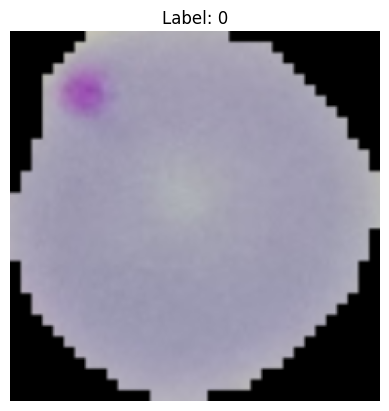

In [12]:
plt.imshow(image)
plt.title(f"Label: {label.numpy()}")
plt.axis("off")
plt.show()

In [13]:
train_processed = train_dataset.map(resize_rescale)
val_processed   = val_dataset.map(resize_rescale)
test_processed  = test_dataset.map(resize_rescale)

In [14]:
for image, label in train_processed.take(1):
    real_image = image
    real_label = label

In [15]:
print("Shape:", real_image.shape)
print("Dtype:", real_image.dtype)
print("Label:", real_label.numpy())
print("Min:", tf.reduce_min(real_image).numpy())
print("Max:", tf.reduce_max(real_image).numpy())

Shape: (224, 224, 3)
Dtype: <dtype: 'float32'>
Label: 0
Min: 0.0
Max: 0.7712097


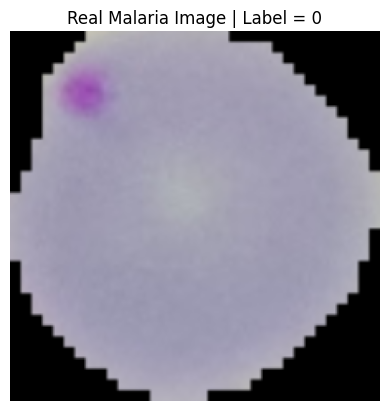

In [16]:
plt.imshow(real_image)
plt.title(f"Real Malaria Image | Label = {real_label.numpy()}")
plt.axis("off")
plt.show()

In [17]:
print(real_image.shape)

(224, 224, 3)


In [18]:
image_batch = tf.expand_dims(
    real_image,
    axis=0
)

print(image_batch.shape)

(1, 224, 224, 3)


In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Conv2D

In [20]:
train_processed = train_dataset.map(resize_rescale)

In [21]:
for image, label in train_processed.take(1):
    real_image = image
    real_label = label

In [22]:
print("Image shape:", real_image.shape)
print("Label:", real_label.numpy())

Image shape: (224, 224, 3)
Label: 1


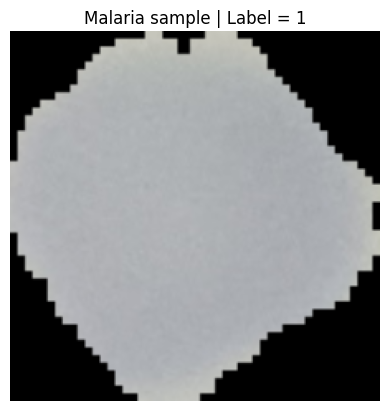

In [23]:
plt.imshow(real_image)
plt.title(f"Malaria sample | Label = {real_label.numpy()}")
plt.axis("off")
plt.show()

In [24]:
image_batch = tf.expand_dims(
    real_image,
    axis=0
)

In [25]:
print("Before:", real_image.shape)
print("After :", image_batch.shape)

Before: (224, 224, 3)
After : (1, 224, 224, 3)


In [26]:
conv_one = Conv2D(
    filters=1,
    kernel_size=5,
    strides=1,
    padding="valid",
    activation=None
)

In [27]:
one_feature_output = conv_one(image_batch)

In [28]:
print("Input :", image_batch.shape)
print("Output:", one_feature_output.shape)

Input : (1, 224, 224, 3)
Output: (1, 220, 220, 1)


In [29]:
feature_map_1 = one_feature_output[0, :, :, 0]

print(feature_map_1.shape)

(220, 220)


In [30]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPool2D,
    Flatten,
    Dense
)

In [32]:
for image, label in train_processed.take(1):
    real_image = image
    real_label = label

print("Image shape:", real_image.shape)
print("Label:", real_label.numpy())

Image shape: (224, 224, 3)
Label: 1


In [33]:
image_batch=tf.expand_dims(real_image,axis=0)



print(real_image.shape)

print(image_batch.shape)



(224, 224, 3)
(1, 224, 224, 3)


In [34]:
conv1 = Conv2D(
    filters=6,
    kernel_size=5,
    strides=1,
    padding="valid",
    activation="sigmoid"
)

In [35]:
x1 = conv1(image_batch)

print("Before Conv1:", image_batch.shape)
print("After Conv1 :", x1.shape)

Before Conv1: (1, 224, 224, 3)
After Conv1 : (1, 220, 220, 6)


In [36]:
conv1_weights,conv1_biases=conv1.get_weights()


print("All Conv1 filters:", conv1_weights.shape)
print("Biases:", conv1_biases.shape)

All Conv1 filters: (5, 5, 3, 6)
Biases: (6,)


In [37]:
## (5,5,5,6),,6 filter ,each filter have 5 rows ,5 colums and each filter 3 slice..
filter_1=conv1_weights[:,:,:,0]

print(filter_1.shape)

(5, 5, 3)


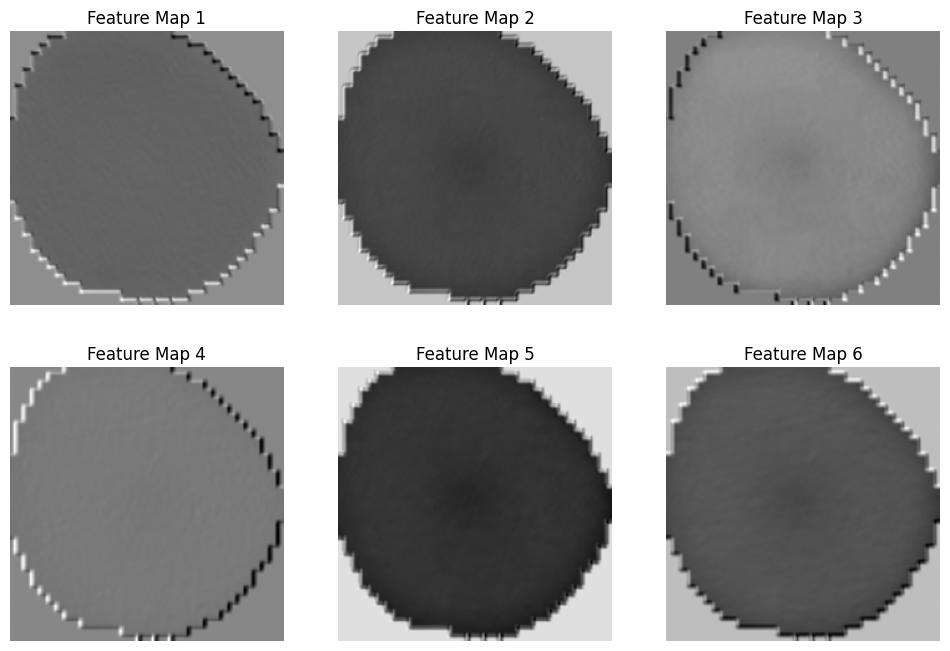

In [38]:
plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    plt.imshow(
        x1[0, :, :, i],
        cmap="gray"
    )

    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.show()

In [39]:
output=conv1(image_batch)

In [40]:
print(output.shape)

(1, 220, 220, 6)


In [41]:
pool1 = MaxPool2D(
    pool_size=2,
    strides=2,
    padding="valid"
)

In [42]:
x2 = pool1(output)

print("Before Pool1:", output.shape)
print("After Pool1 :", x2.shape)

Before Pool1: (1, 220, 220, 6)
After Pool1 : (1, 110, 110, 6)


In [43]:
region=output[0,0:2,0:2,0]

In [44]:
print("mamually calculate max",tf.reduce_max(region).numpy())

mamually calculate max 0.5


In [45]:
conv2 = Conv2D(
    filters=16,
    kernel_size=5,
    strides=1,
    padding="valid",
    activation="sigmoid"
)

In [46]:
x3 = conv2(x2)

print("Before Conv2:", x2.shape)
print("After Conv2 :", x3.shape)

Before Conv2: (1, 110, 110, 6)
After Conv2 : (1, 106, 106, 16)


In [47]:
conv2_weights, conv2_biases = conv2.get_weights()

print(conv2_weights.shape)
print(conv2_biases.shape)

(5, 5, 6, 16)
(16,)


In [48]:
pool2 = MaxPool2D(
    pool_size=2,
    strides=2,
    padding="valid"
)

In [49]:
x4 = pool2(x3)

print("Before Pool2:", x3.shape)
print("After Pool2 :", x4.shape)

Before Pool2: (1, 106, 106, 16)
After Pool2 : (1, 53, 53, 16)


In [50]:
flatten = Flatten()

x5 = flatten(x4)

print("Before Flatten:", x4.shape)
print("After Flatten :", x5.shape)

Before Flatten: (1, 53, 53, 16)
After Flatten : (1, 44944)


In [51]:
dense1 = Dense(
    100,
    activation="sigmoid"
)

x6 = dense1(x5)

print("Input :", x5.shape)
print("Output:", x6.shape)
print("Params:", dense1.count_params())

Input : (1, 44944)
Output: (1, 100)
Params: 4494500


In [52]:
dense2 = Dense(
    10,
    activation="sigmoid"
)

x7 = dense2(x6)

print("Output:", x7.shape)
print("Params:", dense2.count_params())

Output: (1, 10)
Params: 1010


In [53]:
output_layer = Dense(1, activation="sigmoid")

x8 = output_layer(x7)

print("Output shape:", x8.shape)
print("Parameters:", output_layer.count_params())
print("Raw outputs:", x8.numpy())

Output shape: (1, 1)
Parameters: 11
Raw outputs: [[0.31073084]]


In [54]:
model = tf.keras.Sequential([

    Input(shape=(IM_SIZE, IM_SIZE, 3)),

    Conv2D(
        filters=6,
        kernel_size=5,
        strides=1,
        padding="valid",
        activation="sigmoid"
    ),

    MaxPool2D(
        pool_size=2,
        strides=2
    ),

    Conv2D(
        filters=16,
        kernel_size=5,
        strides=1,
        padding="valid",
        activation="sigmoid"
    ),

    MaxPool2D(
        pool_size=2,
        strides=2
    ),

    Flatten(),

    Dense(100, activation="sigmoid"),

    Dense(10, activation="sigmoid"),

    Dense(1, activation="sigmoid")
])

# 06 - Training and Evaluation

In this notebook, I will train the baseline CNN,
evaluate its performance, and analyze predictions.

05 → architecture বানিয়েছি

06 → architecture-কে শেখাব

## 1. Binary Cross Entropy Loss

In [55]:
import tensorflow as tf

In [56]:
y_true = [0, 1, 0, 0]
y_pred = [0.2, 0.9, 0.1, 0.0]

In [57]:
y_true = [0, 1, 0, 0]
y_pred = [0.2, 0.9, 0.1, 0.0]

bce = tf.keras.losses.BinaryCrossentropy()
print(bce(y_true, y_pred))

tf.Tensor(0.108466186, shape=(), dtype=float32)


Sample 1: y=0, ŷ=0.2
         loss = -log(1 - 0.2)
              = -log(0.8)
              ≈ 0.223

Sample 2: y=1, ŷ=0.9
         loss = -log(0.9)
              ≈ 0.105

Sample 3: y=0, ŷ=0.1
         loss = -log(0.9)
              ≈ 0.105

Sample 4: y=0, ŷ=0.0
         loss ≈ 0

avg of 4 sample=0.108

In [58]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [59]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

# compile = configuration or setting rules
# optimizer= how to update weight after finding gd

## 2. Preparing the Dataset for Training

The datasets are shuffled, batched, and prefetched before training.

In [60]:
BATCH_SIZE = 32

# 3.  training dataset prepare

In [61]:
BATCH_SIZE = 32

train_ready = (
    train_processed
    .shuffle(
        buffer_size=1000,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ready = (
    val_processed
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ready = (
    test_processed
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [62]:
for images, labels in train_ready.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Images dtype:", images.dtype)
    print("Labels:", labels[:10].numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Images dtype: <dtype: 'float32'>
Labels: [0 0 1 0 1 1 0 1 0 0]


In [79]:
model = tf.keras.Sequential([

    Input(shape=(IM_SIZE, IM_SIZE, 3)),

    Conv2D(
        filters=6,
        kernel_size=5,
        strides=1,
        padding="valid",
        activation="sigmoid"
    ),

    MaxPool2D(
        pool_size=2,
        strides=2
    ),

    Conv2D(
        filters=16,
        kernel_size=5,
        strides=1,
        padding="valid",
        activation="sigmoid"
    ),

    MaxPool2D(
        pool_size=2,
        strides=2
    ),

    Flatten(),

    Dense(100, activation="sigmoid"),
    Dense(10, activation="sigmoid"),

    Dense(1, activation="sigmoid")
])

In [80]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 220, 220, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 110, 110, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 106, 106, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 53, 53, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 44944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │     4,494,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,498,393 (17.16 MB)

 Trainable params: 4,498,393 (17.16 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 220, 220, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 110, 110, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 106, 106, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 53, 53, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 44944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │     4,494,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,498,393 (17.16 MB)

 Trainable params: 4,498,393 (17.16 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
for images, labels in train_ready.take(1):

    predictions = model(images)

    print("Images      :", images.shape)
    print("Labels      :", labels.shape)
    print("Predictions :", predictions.shape)

Images      : (32, 224, 224, 3)
Labels      : (32,)
Predictions : (32, 1)


In [83]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        )
    ]
)

In [84]:
EPOCHS = 10

In [85]:
history = model.fit(
    train_ready,
    validation_data=val_ready,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.4933 - loss: 0.6958 - val_accuracy: 0.5112 - val_loss: 0.6929
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.4994 - loss: 0.6939 - val_accuracy: 0.5112 - val_loss: 0.6929
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.5007 - loss: 0.6939 - val_accuracy: 0.5112 - val_loss: 0.6929
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4968 - loss: 0.6938 - val_accuracy: 0.5112 - val_loss: 0.6930
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.4964 - loss: 0.6938 - val_accuracy: 0.5112 - val_loss: 0.6930
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.4988 - loss: 0.6936 - val_accuracy: 0.5112 - val_loss: 0.6931
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.5018 - loss: 0.6935 - val_accuracy: 0.5112 - val_loss: 0.6929
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.4958 - loss: 0.6935 - 

In [86]:
from tensorflow.keras.layers import BatchNormalization

In [94]:
improved_model = tf.keras.Sequential([

    Input(shape=(IM_SIZE, IM_SIZE, 3)),

    Conv2D(
        filters=6,
        kernel_size=3,
        strides=1,
        padding="valid",
        activation="relu"
    ),

    BatchNormalization(),

    MaxPool2D(
        pool_size=2,
        strides=2
    ),

    Conv2D(
        filters=16,
        kernel_size=3,
        strides=1,
        padding="valid",
        activation="relu"
    ),

    BatchNormalization(),

    MaxPool2D(
        pool_size=2,
        strides=2
    ),

    Flatten(),

    Dense(
        100,
        activation="relu"
    ),

    BatchNormalization(),

    Dense(
        10,
        activation="relu"
    ),

    BatchNormalization(),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [88]:
improved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

In [92]:
for images, labels in train_ready.take(1):

    predictions = improved_model(images)

    print("Images      :", images.shape)
    print("Labels      :", labels.shape)
    print("Predictions :", predictions.shape)

Images      : (32, 224, 224, 3)
Labels      : (32,)
Predictions : (32, 1)


In [100]:
 improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        )
    ]
)

In [101]:
improved_history = improved_model.fit(
    train_ready,
    validation_data=val_ready,
    epochs=5,
    verbose=1
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.8545 - loss: 0.3420 - val_accuracy: 0.4775 - val_loss: 0.9651
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.9222 - loss: 0.2112 - val_accuracy: 0.8777 - val_loss: 0.3702
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.9203 - loss: 0.2106 - val_accuracy: 0.9285 - val_loss: 0.2044
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.9421 - loss: 0.1602 - val_accuracy: 0.9318 - val_loss: 0.2128
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.9555 - loss: 0.1248 - val_accuracy: 0.9024 - val_loss: 0.2977
